Data-preprocessing, ML

In [43]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Assignment-DM/COM6013-DataMiningDataset.xlsx')

#read, display the first rows in the dataset

print(df.head()) # get the first rows

     ID       Date Country(UK)     City Confectionary  Units Sold  \
0  1038 2023-12-31       Wales  Cardiff         Jelly      1914.0   
1  1111 2025-12-30     Ireland   Galway         jelly      2382.0   
2  1742 2025-11-30     Ireland     Cork       Caramel      2943.0   
3  1060 2025-11-29     England   London         Fudge      1793.0   
4   116 2025-10-27     Ireland   Galway         jelly      2621.0   

   Price per Unit (£)  Cost per Unit (£)  Revenue(£)  Cost(£)  Profit(£)  
0                5.46               2.23    10450.44  4268.22    6182.22  
1                5.34               2.38    12719.88  5669.16    7050.72  
2                5.30               2.25    15597.90  6621.75    8976.15  
3                5.20               2.17     9323.60  3890.81    5432.79  
4                4.74               2.30    12423.54  6028.30    6395.24  


Remove Extra Spaces for Columns and list them

In [44]:
# Clean column names (to remove any extra spaces)
df.columns = df.columns.str.strip()

print("\nCleaned column names:")
print(df.columns.tolist())


Cleaned column names:
['ID', 'Date', 'Country(UK)', 'City', 'Confectionary', 'Units Sold', 'Price per Unit (£)', 'Cost per Unit (£)', 'Revenue(£)', 'Cost(£)', 'Profit(£)']


In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Check Duplicate Values

In [46]:
#check for any duplicate values.
df.duplicated()

#check rows
df.shape[0]

#drop duplicates.
df.drop_duplicates()


,ID,Date,Country(UK),City,Confectionary,Units Sold,Price per Unit (£),Cost per Unit (£),Revenue(£),Cost(£),Profit(£)
0,1038,2023-12-31,Wales,Cardiff,Jelly,1914.0,5.46,2.23,10450.44,4268.22,6182.22
1,1111,2025-12-30,Ireland,Galway,jelly,2382.0,5.34,2.38,12719.88,5669.16,7050.72
2,1742,2025-11-30,Ireland,Cork,Caramel,2943.0,5.30,2.25,15597.90,6621.75,8976.15
3,1060,2025-11-29,England,London,Fudge,1793.0,5.20,2.17,9323.60,3890.81,5432.79
4,116,2025-10-27,Ireland,Galway,jelly,2621.0,4.74,2.30,12423.54,6028.30,6395.24
...,...,...,...,...,...,...,...,...,...,...,...
1995,968,2021-01-05,Scotland,Dundee,Chocolate,1898.0,5.52,2.60,10476.96,4934.80,5542.16
1996,65,2021-01-03,Ireland,Galway,Jelly,NaN,NaN,NaN,0.00,0.00,0.00
1997,1792,2021-01-03,Wales,Newport,Caramel,3349.0,5.87,2.95,19658.63,9879.55,9779.08
1998,1989,2021-01-03,Scotland,Edinburgh,Jelly,1454.0,4.42,2.43,6426.68,3533.22,2893.46


Check for missing values

In [47]:
#check missing values
df.isnull().sum()


,0
ID,0
Date,0
Country(UK),0
City,0
Confectionary,0
Units Sold,99
Price per Unit (£),99
Cost per Unit (£),99
Revenue(£),0
Cost(£),0


Handle missing values

In [48]:
# get mean and replace the nulls

df['Units Sold'].fillna(df['Units Sold'].mean(), inplace=True)

df['Price per Unit (£)'].fillna(df['Price per Unit (£)'].mean(), inplace=True)

df['Cost per Unit (£)'].fillna(df['Cost per Unit (£)'].mean(), inplace=True)
df

#check no nulls in the dataset
df.isnull().sum()


#check zero and replace them with nan in the dataset
df['Revenue(£)'] = df['Revenue(£)'].replace(0, np.nan)
df['Revenue(£)'].fillna(df['Revenue(£)'].mean(), inplace=True)


df['Cost(£)'] = df['Cost(£)'].replace(0, np.nan)
df['Cost(£)'].fillna(df['Cost(£)'].mean(), inplace=True)


df['Profit(£)'] = df['Profit(£)'].replace(0, np.nan)
df['Profit(£)'].fillna(df['Profit(£)'].mean(), inplace=True)
df.describe()



/tmp/ipykernel_2582/3732647264.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Units Sold'].fillna(df['Units Sold'].mean(), inplace=True)
/tmp/ipykernel_2582/3732647264.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

,ID,Date,Units Sold,Price per Unit (£),Cost per Unit (£),Revenue(£),Cost(£),Profit(£)
count,2000.000000,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2023-07-01 02:42:43.200000,1961.849553,5.095639,2.451063,9994.336186,4812.203993,5182.132194
min,1.000000,2021-01-01 00:00:00,324.000000,4.300000,1.740000,1869.480000,767.880000,1101.600000
25%,500.750000,2022-03-17 06:00:00,1594.000000,4.720000,2.230000,7948.462500,3782.092500,4055.652500
50%,1000.500000,2023-07-23 12:00:00,1939.000000,5.095639,2.450000,9863.620000,4717.890000,5085.515000
75%,1500.250000,2024-10-05 00:00:00,2301.000000,5.480000,2.660000,11717.000000,5661.745000,6126.945000
max,2000.000000,2025-12-30 00:00:00,3959.000000,5.900000,3.280000,23160.150000,10768.480000,12391.670000
std,577.494589,NaN,541.569413,0.446331,0.317843,2916.658135,1501.213960,1565.571988


In [49]:
#Summary statistics
df.describe()


,ID,Date,Units Sold,Price per Unit (£),Cost per Unit (£),Revenue(£),Cost(£),Profit(£)
count,2000.000000,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2023-07-01 02:42:43.200000,1961.849553,5.095639,2.451063,9994.336186,4812.203993,5182.132194
min,1.000000,2021-01-01 00:00:00,324.000000,4.300000,1.740000,1869.480000,767.880000,1101.600000
25%,500.750000,2022-03-17 06:00:00,1594.000000,4.720000,2.230000,7948.462500,3782.092500,4055.652500
50%,1000.500000,2023-07-23 12:00:00,1939.000000,5.095639,2.450000,9863.620000,4717.890000,5085.515000
75%,1500.250000,2024-10-05 00:00:00,2301.000000,5.480000,2.660000,11717.000000,5661.745000,6126.945000
max,2000.000000,2025-12-30 00:00:00,3959.000000,5.900000,3.280000,23160.150000,10768.480000,12391.670000
std,577.494589,NaN,541.569413,0.446331,0.317843,2916.658135,1501.213960,1565.571988


Exploratory Data Analysis (EDA).

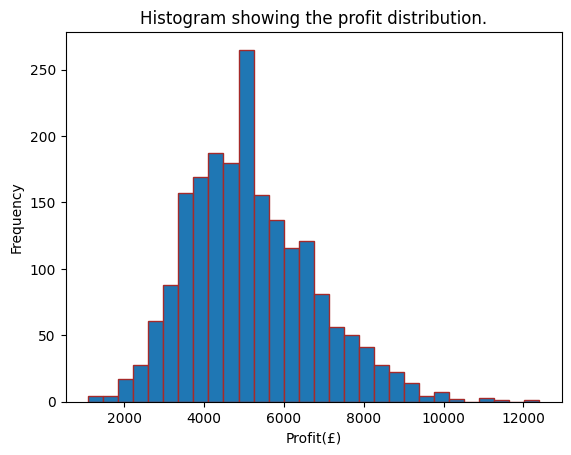

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

<Figure size 1200x800 with 0 Axes>

In [50]:
# Create the Histogram, Distribution of Profit.
plt.title('Histogram showing the profit distribution.')
plt.hist(df['Profit(£)'], bins=30, edgecolor='brown')
plt.xlabel('Profit(£)')
plt.ylabel('Frequency')
plt.show()
plt.figure(figsize=(12, 8))
plt

Distribution of units sold

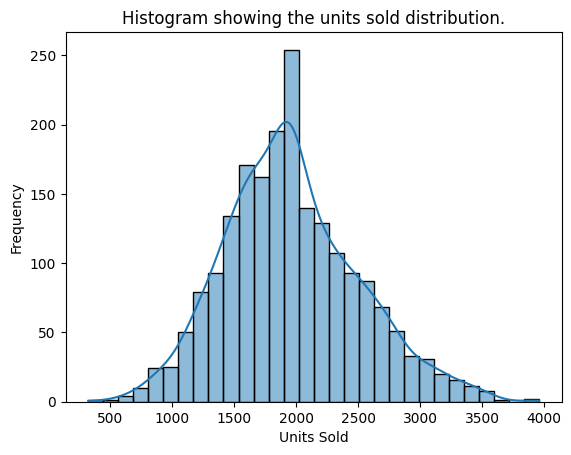

In [51]:
sns.histplot(data=df, x ="Units Sold", kde=True, bins=30)
plt.title('Histogram showing the units sold distribution.')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.show()

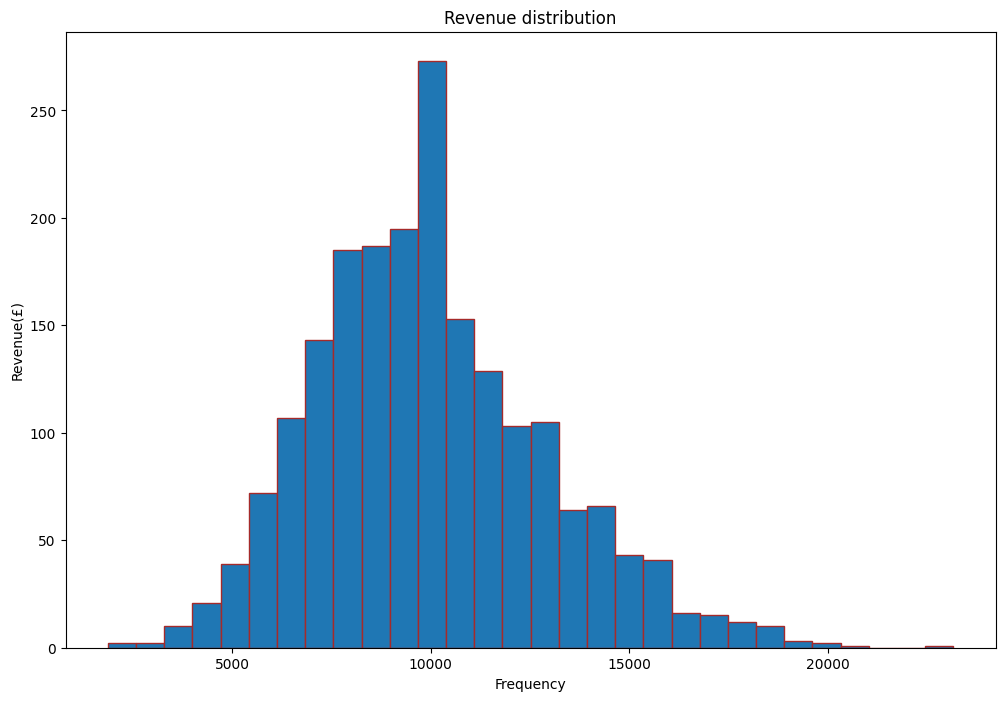

In [52]:
#Graph showing revenue over time
plt.figure(figsize=(12, 8))
#sns.scatterplot(x=df['Date'], y=df['Revenue(£)'])
plt.hist(df['Revenue(£)'], bins=30, edgecolor='brown')
plt.title('Revenue distribution')
plt.xlabel('Frequency')
plt.ylabel('Revenue(£)')
plt.show()

Graph showing Units Sold over time

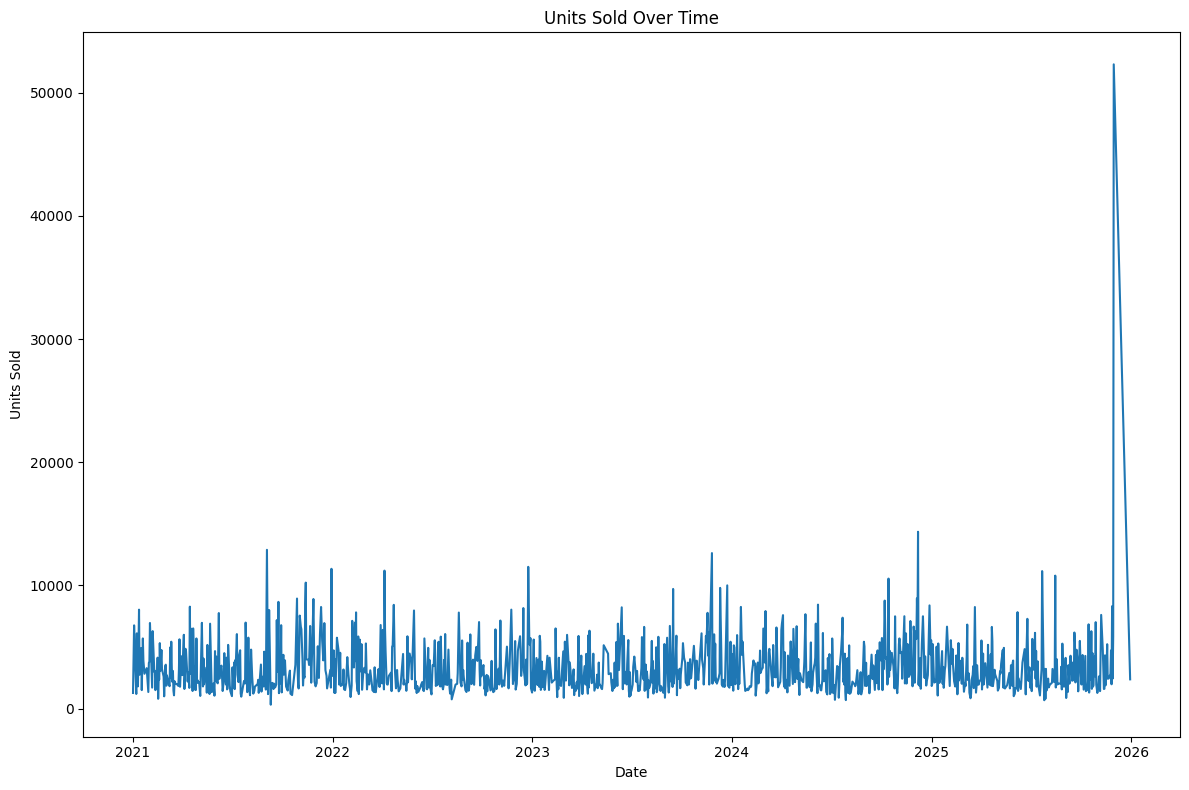

In [53]:
#make sure all date values are in datetime
df['Date'] = pd.to_datetime(df['Date'])

#aggregate all
daily_summary = (
    df.groupby('Date', as_index=False)
      .agg(
          units_sold=('Units Sold', 'sum')
      )
)

plt.figure(figsize=(12, 8))

sns.lineplot(
    data=daily_summary,
    x='Date',
    y='units_sold'
)

plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.title('Units Sold Over Time')

plt.tight_layout()
plt.show()

Implement graph  for Profit over time

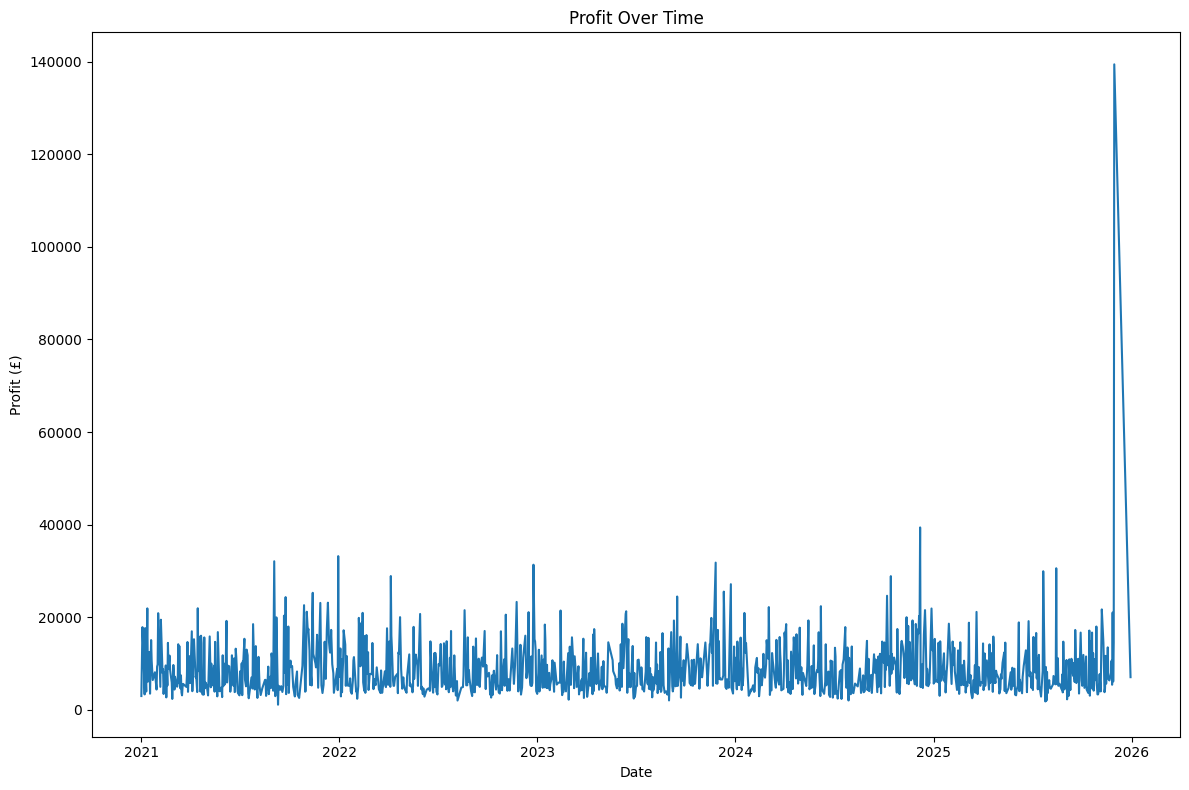

In [54]:
#implement profit over time
#make date values are in datetime
df['Date'] = pd.to_datetime(df['Date'])
#aggregate all

daily_summary = (
    df.groupby('Date', as_index=False)
      .agg(
          profit=('Profit(£)', 'sum')
      )
)


plt.figure(figsize=(12, 8))

sns.lineplot(
    data=daily_summary,
    x='Date',
    y='profit'
)

plt.xlabel('Date')
plt.ylabel('Profit (£)')
plt.title('Profit Over Time')

plt.tight_layout()
plt.show()


Implement Profit gainded from each country


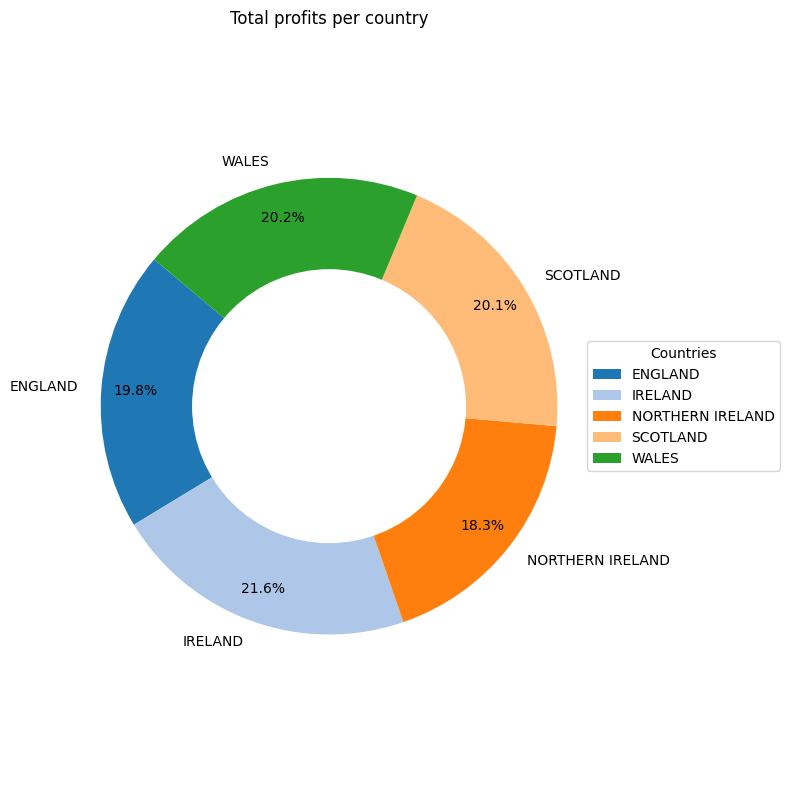

In [55]:
# Standardize country names to uppercase
df['Country(UK)'] = df['Country(UK)'].str.upper().str.strip()

# Aggregate the profit by country
profit_by_country = df.groupby('Country(UK)')['Profit(£)'].sum().reset_index()

# Create a donut chart
plt.figure(figsize=(8, 8))
plt.pie(
    profit_by_country['Profit(£)'],
    labels=profit_by_country['Country(UK)'],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.tab20.colors,
    pctdistance=0.85,
)

# Draw a circle at the center to turn the pie into a donut chart
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')
plt.title('Total profits per country')
plt.legend(profit_by_country['Country(UK)'], title="Countries", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.tight_layout()
plt.show()


Visualization for Profit gained from each Confectionary

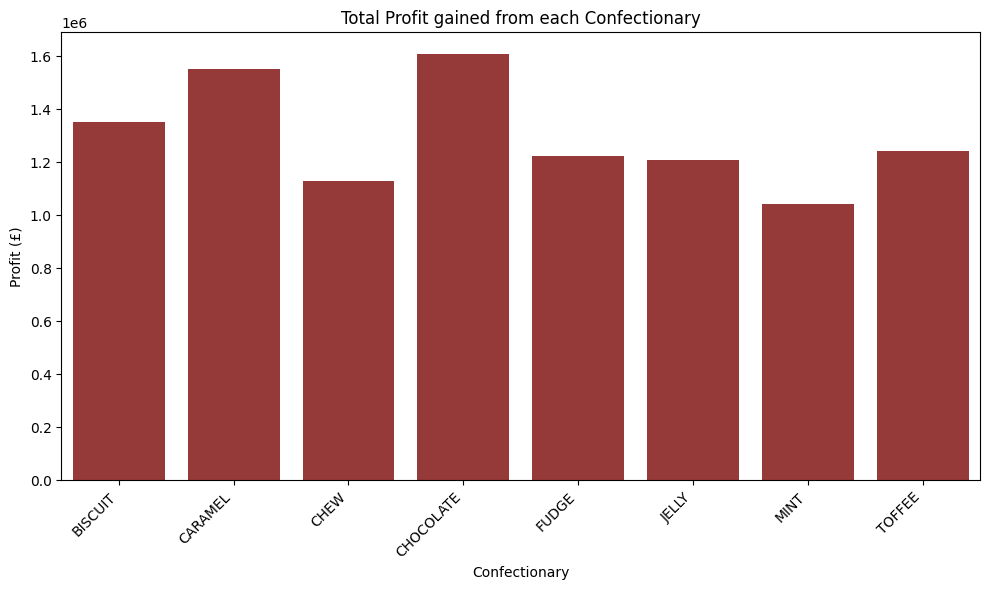

In [56]:
# Standardize confectionary names to uppercase
df['Confectionary'] = df['Confectionary'].str.upper().str.strip()

#Aggregate the profit by for the Confectionary names
profit_by_confectionary = (
    df.groupby('Confectionary', as_index=False)['Profit(£)']
      .sum()
)

#create barplot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=profit_by_confectionary,
    x='Confectionary',
    y='Profit(£)',
    color='brown'
    )

plt.xticks(rotation=45, ha='right')
plt.xlabel('Confectionary')
plt.ylabel('Profit (£)')
plt.title('Total Profit gained from each Confectionary')

plt.tight_layout()
plt.show()

Implement Revenue over Profit.

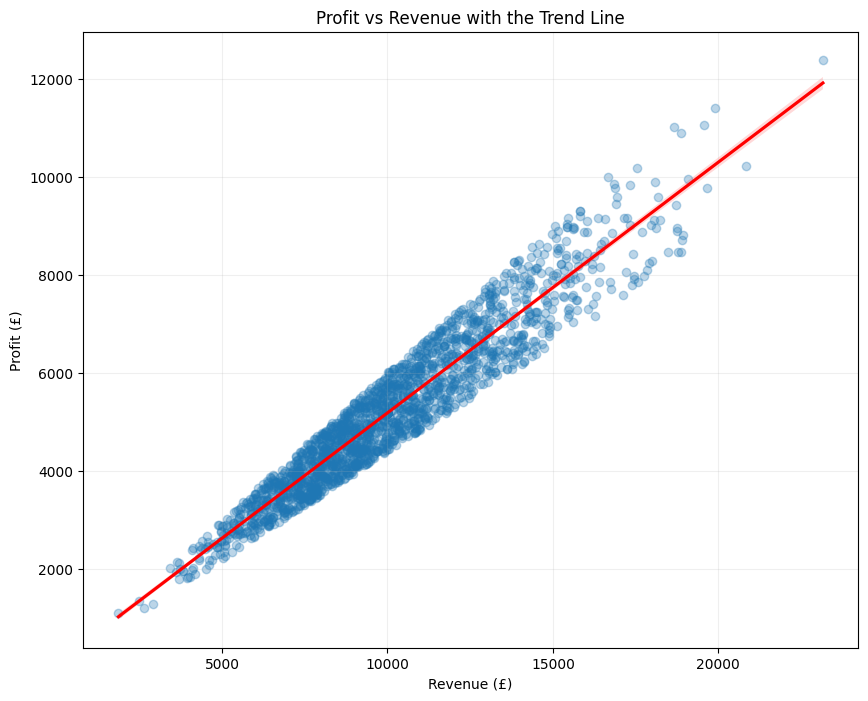

In [57]:
#Implement Revenue over Profit.
plt.figure(figsize=(10, 8))
sns.regplot(x=df['Revenue(£)'], y=df['Profit(£)'],
            scatter_kws={'alpha':0.3},
            line_kws={'color':'red'}
            )
plt.xlabel('Revenue (£)')
plt.ylabel('Profit (£)')
plt.title('Profit vs Revenue with the Trend Line')
plt.grid(True, alpha=0.2)
plt.show()


Visualize the Units Sold and the Revenue

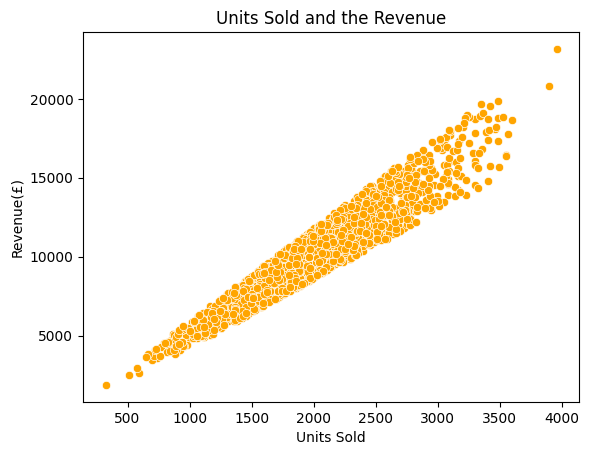

In [58]:
sns.scatterplot(x="Units Sold", y="Revenue(£)", data=df , color="orange")
plt.title("Units Sold and the Revenue")
plt.show()

Outlier Detection in Revenue

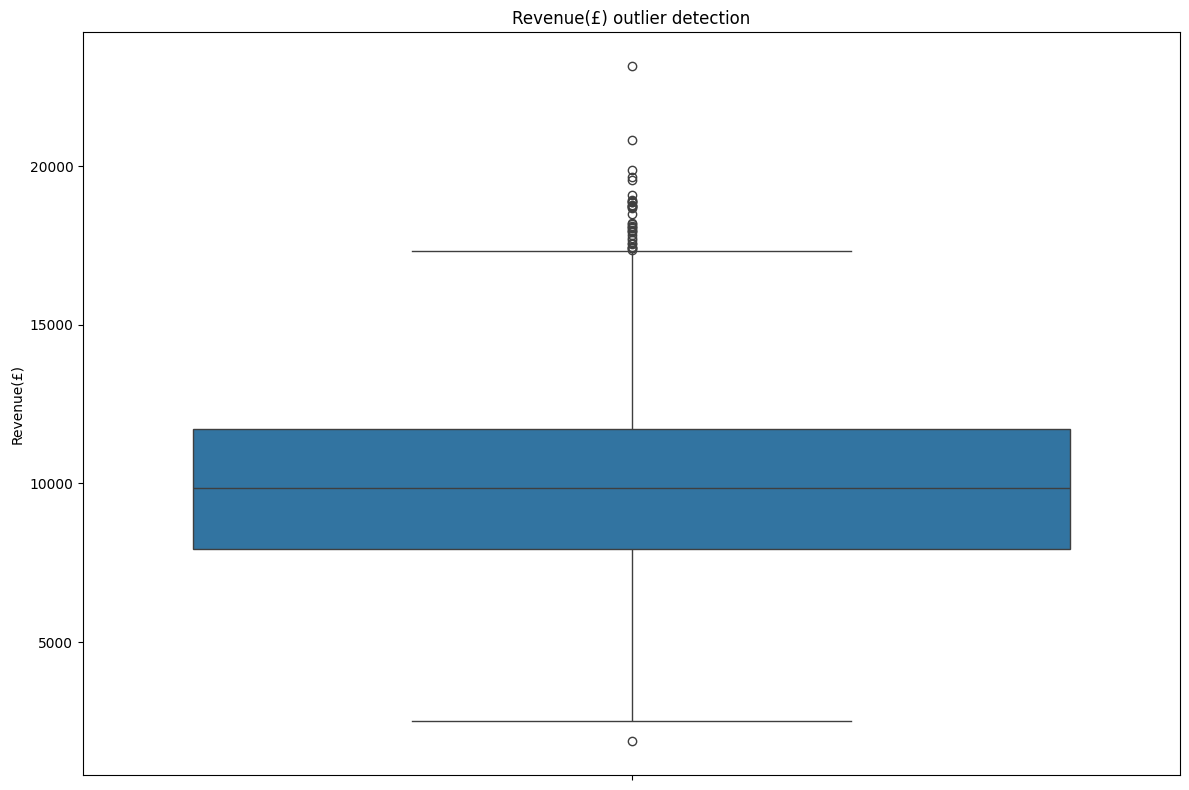

In [59]:
#detect outliers in revenue
plt.figure(figsize=(12, 8))

sns.boxplot(y=df['Revenue(£)'])

plt.ylabel('Revenue(£)')
plt.title('Revenue(£) outlier detection')

plt.tight_layout()
plt.show()

Outlier Dectection in Units Sold

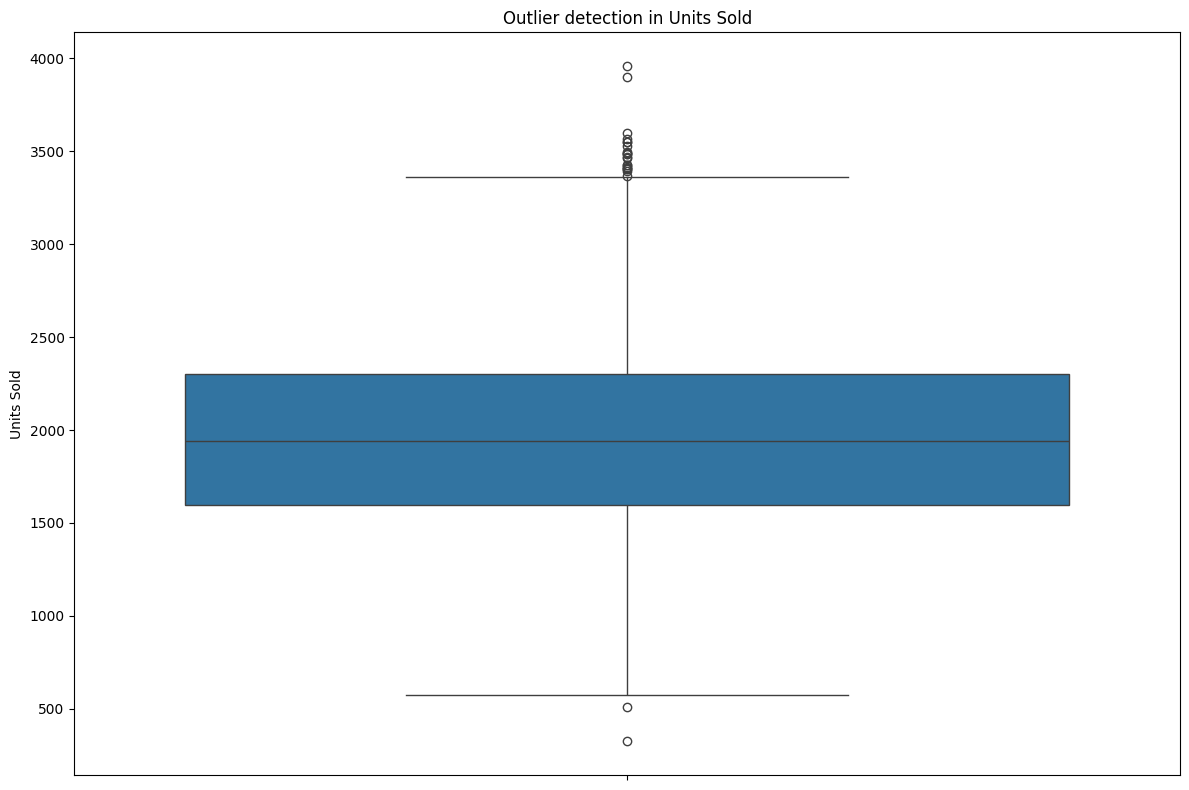

In [60]:
plt.figure(figsize =(12, 8))
sns.boxplot(y=df['Units Sold'])
plt.ylabel('Units Sold')
plt.title('Outlier detection in Units Sold')

plt.tight_layout()
plt.show()

Outlier detection in Profit

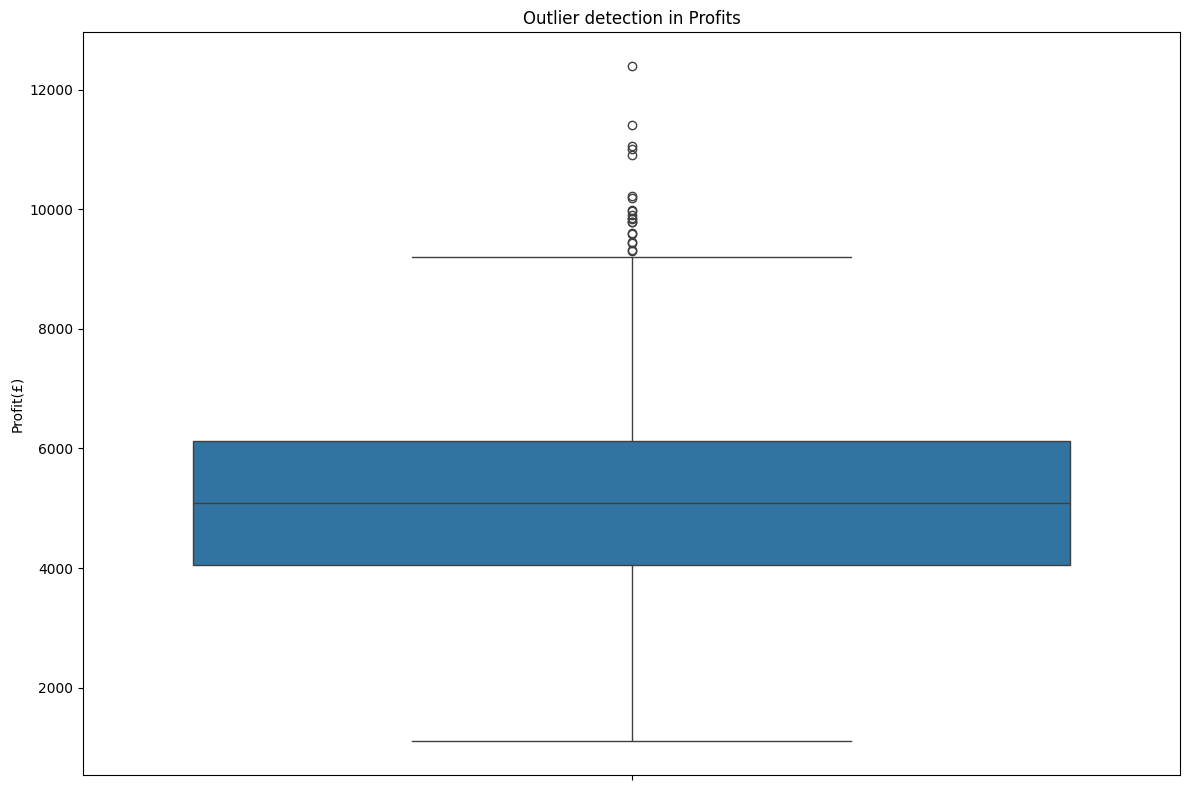

In [61]:
plt.figure(figsize=(12,8))
sns.boxplot(y=df['Profit(£)'])

plt.ylabel('Profit(£)')
plt.title('Outlier detection in Profits')

plt.tight_layout()
plt.show()

Outlier detection in Cost

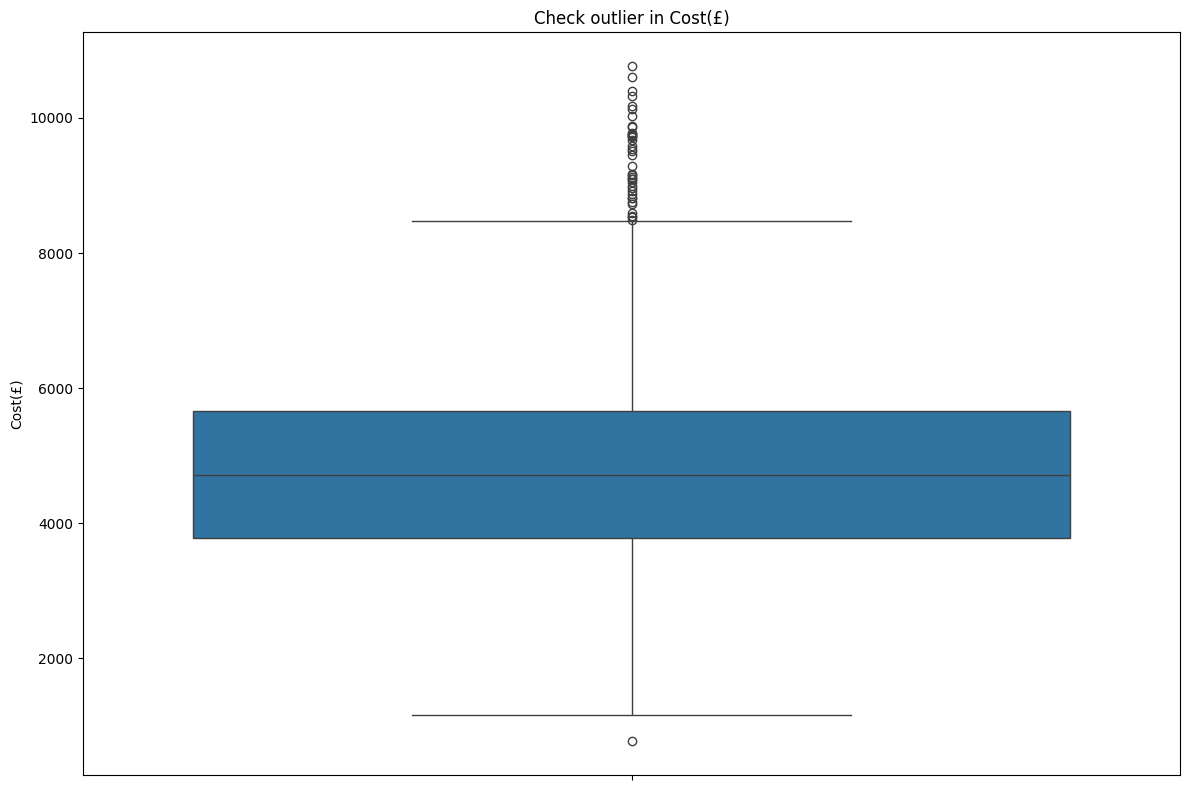

In [62]:
plt.figure(figsize=(12, 8))

sns.boxplot(y=df['Cost(£)'])

plt.ylabel('Cost(£)')
plt.title('Check outlier in Cost(£)')

plt.tight_layout()
plt.show()

Check Outlier in Cost per Unit

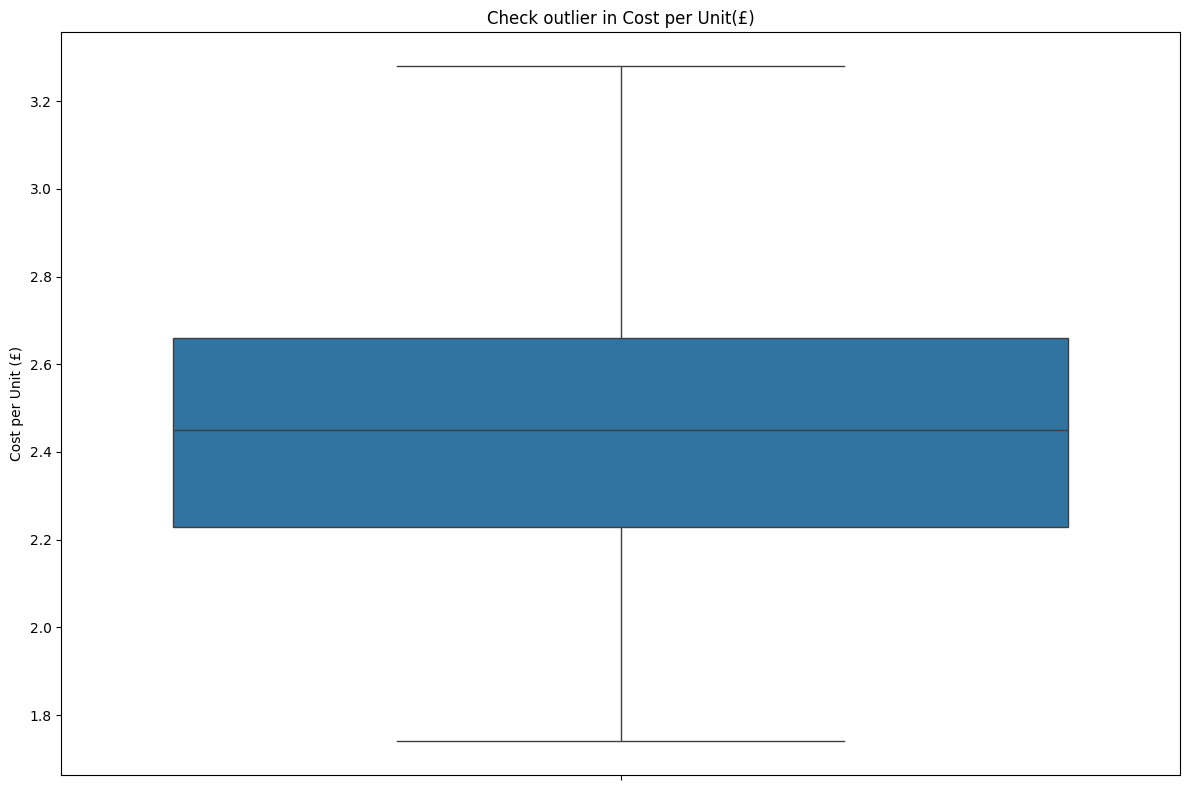

In [63]:
plt.figure(figsize=(12, 8))
sns.boxplot(y=df['Cost per Unit (£)'])

plt.ylabel('Cost per Unit (£)')
plt.title('Check outlier in Cost per Unit(£)')

plt.tight_layout()

Handling Outliers

Check for any negative values in the profits, Units sold and Revenue

In [64]:
#check any negative values
df[df["Units Sold"] < 0]

df[df['Revenue(£)'] < 0]

#check if profit is greater than revenue

df[df['Profit(£)'] > df['Revenue(£)']]

#check the difference between revenue aand unit sold, see if we have renveu for 0 units sold

df.loc[(df["Revenue(£)"] == 0) & (df["Units Sold"] > 0)]

,ID,Date,Country(UK),City,Confectionary,Units Sold,Price per Unit (£),Cost per Unit (£),Revenue(£),Cost(£),Profit(£)


In [65]:
#detect outliers in profit , Revenue
def detect_outliers(df, columns):
  bounds = {}
  for col in columns:
      Q1 = df[col].quantile(0.25);
      Q3 = df[col].quantile(0.75);
      IQR = Q3 - Q1;
      lower = Q1 - 1.5 * IQR;
      upper = Q3 + 1.5 * IQR;

      df[f"{col}_outlier"] = (df[col] < lower) | (df[col] > upper)
      print(f"{col}_outlier created") #see created func
      bounds[col] = (lower, upper)


  return bounds

Visualize the outliers

In [66]:
#profit outlier per country
detect_outliers(df, ["Revenue(£)", "Profit(£)"])
df.groupby("Country(UK)")["Profit(£)_outlier"].sum()


Revenue(£)_outlier created
Profit(£)_outlier created


,Profit(£)_outlier
Country(UK),
ENGLAND,0
IRELAND,6
NORTHERN IRELAND,3
SCOTLAND,4
WALES,7


In [67]:
#revenvue outliner per country
df.groupby("Country(UK)")["Revenue(£)_outlier"].sum()

,Revenue(£)_outlier
Country(UK),
ENGLAND,6
IRELAND,10
NORTHERN IRELAND,6
SCOTLAND,4
WALES,8


In [68]:
#see current cols

df.columns

Index(['ID', 'Date', 'Country(UK)', 'City', 'Confectionary', 'Units Sold',
       'Price per Unit (£)', 'Cost per Unit (£)', 'Revenue(£)', 'Cost(£)',
       'Profit(£)', 'Revenue(£)_outlier', 'Profit(£)_outlier'],
      dtype='object')

Log Transformation

In [69]:
df["log_profit"] = np.log1p(df["Profit(£)"])
df["log_revenue"] = np.log1p(df["Revenue(£)"])

In [70]:
df.columns

Index(['ID', 'Date', 'Country(UK)', 'City', 'Confectionary', 'Units Sold',
       'Price per Unit (£)', 'Cost per Unit (£)', 'Revenue(£)', 'Cost(£)',
       'Profit(£)', 'Revenue(£)_outlier', 'Profit(£)_outlier', 'log_profit',
       'log_revenue'],
      dtype='object')

Parse the date column

In [71]:
df["date"] = pd.to_datetime(df["Date"])
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month

Visualize the outlier per country

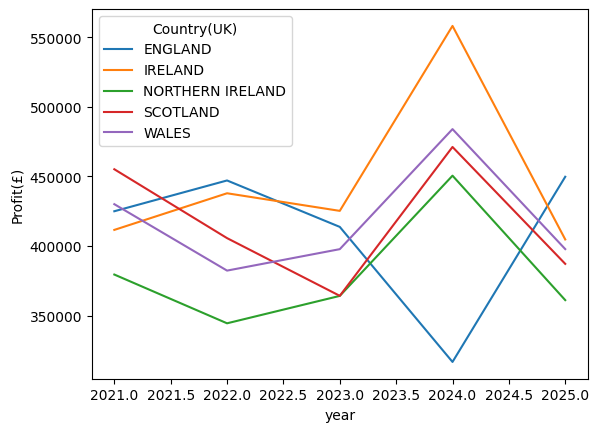

In [72]:
country_year = df.groupby(["Country(UK)", "year"])["Profit(£)"].sum().reset_index()

sns.lineplot(data=country_year, x="year", y="Profit(£)", hue="Country(UK)")
plt.show()

Revenue Distribution

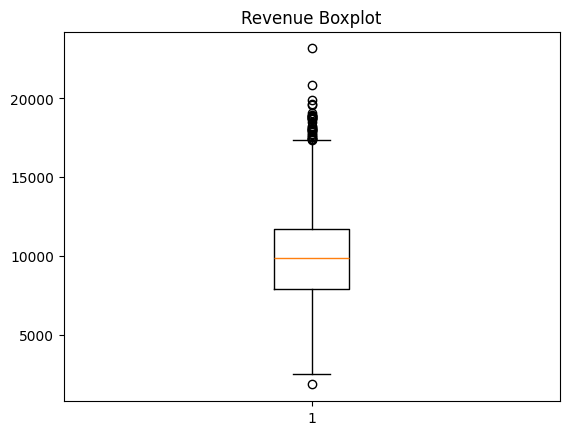

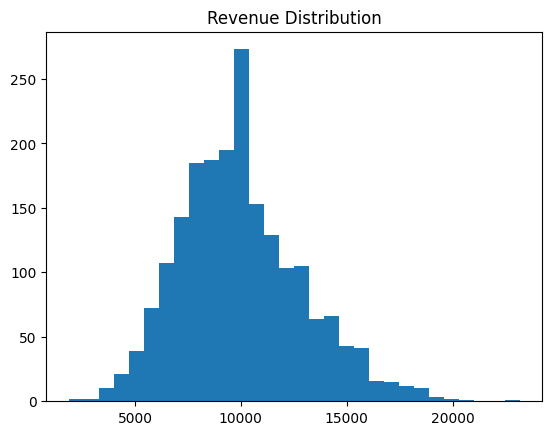

In [73]:


plt.boxplot(df["Revenue(£)"])
plt.title("Revenue Boxplot")
plt.show()

plt.hist(df["Revenue(£)"], bins=30)
plt.title("Revenue Distribution")
plt.show()

Cross-varaible Consistency Check

In [74]:
df.sort_values("Revenue(£)", ascending=False).head(10)


,ID,Date,Country(UK),City,Confectionary,Units Sold,Price per Unit (£),Cost per Unit (£),Revenue(£),Cost(£),Profit(£),Revenue(£)_outlier,Profit(£)_outlier,log_profit,log_revenue,date,year,month
875,1857,2023-11-08,WALES,Cardiff,CHOCOLATE,3959.0,5.85,2.72,23160.15,10768.48,12391.67,True,True,9.424860,10.050232,2023-11-08,2023,11
1266,140,2022-11-03,IRELAND,Limerick,CHOCOLATE,3900.0,5.34,2.72,20826.00,10608.00,10218.00,True,True,9.232004,9.944006,2022-11-03,2022,11
416,1110,2024-12-06,IRELAND,Dublin,CARAMEL,3489.0,5.70,2.43,19887.30,8478.27,11409.03,True,True,9.342248,9.897887,2024-12-06,2024,12
1997,1792,2021-01-03,WALES,Newport,CARAMEL,3349.0,5.87,2.95,19658.63,9879.55,9779.08,True,True,9.188103,9.886323,2021-01-03,2021,1
1263,595,2022-11-04,SCOTLAND,Glasgow,CARAMEL,3425.0,5.71,2.48,19556.75,8494.00,11062.75,True,True,9.311429,9.881127,2022-11-04,2022,11
1613,198,2021-12-11,NORTHERN IRELAND,Lisburn,CHOCOLATE,3366.0,5.67,2.71,19085.22,9121.86,9963.36,True,True,9.206770,9.856722,2021-12-11,2021,12
1456,407,2022-04-25,NORTHERN IRELAND,Belfast,CARAMEL,3238.0,5.85,3.13,18942.30,10134.94,8807.36,True,False,9.083457,9.849206,2022-04-25,2022,4
424,19,2024-12-03,IRELAND,Limerick,CHOCOLATE,3339.0,5.66,3.05,18898.74,10183.95,8714.79,True,False,9.072892,9.846903,2024-12-03,2024,12
57,1686,2025-11-07,ENGLAND,London,CHOCOLATE,3527.0,5.35,2.95,18869.45,10404.65,8464.80,True,False,9.043790,9.845352,2025-11-07,2025,11
1268,1368,2022-11-01,WALES,Newport,CHOCOLATE,3253.0,5.80,2.45,18867.40,7969.85,10897.55,True,True,9.296385,9.845244,2022-11-01,2022,11


Check Correlation: To quantify the relationship between Revenue and profit.


In [75]:
# Calculate correlation to quantify the relationship
correlation = df['Revenue(£)'].corr(df['Profit(£)'])
print(f"Correlation between Revenue and Profit: {correlation:.3f}")

Correlation between Revenue and Profit: 0.953


Data Modeling

In [76]:
#split data into Features
#split by mean

mean_profit = df["Profit(£)"].mean() # create average profit
df["Profit_class"] = (df["Profit(£)"] > mean_profit).astype(int)

#Binanry Classification

X = df[["Units Sold"]]
y = df["Profit_class"] # binary 1 = high, 0 for low.

#check classification
print('Class distribution:')
print(y.value_counts())
print(f"/nHigh Profit (1): {(y == 1).sum()}")
print(f"Low Profit(0): {(y == 0).sum()}")

Class distribution:
Profit_class
0    1133
1     867
Name: count, dtype: int64
/nHigh Profit (1): 867
Low Profit(0): 1133


Split the data, Train and Test

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

Train and inspect the model

In [78]:
model = LogisticRegression(solver="liblinear", random_state=42)
model.fit(X_train, y_train)

LogisticRegression(random_state=42, solver='liblinear')

In [79]:
print("Intercept (β0):", model.intercept_[0])
print("Coefficient for profits (β1):", model.coef_[0][0])

Intercept (β0): -9.727274695217826
Coefficient for profits (β1): 0.004787113069233166


Make predictions

In [80]:
Probability = model.predict_proba(X_test)[:, 1] #Probability of high=1
pred_default = model.predict(X_test) #Default threshold = 0.5

Evaluate Performance model

In [81]:
print("Accuracy", accuracy_score(y_test, pred_default))
print("Confusion Matrix:/n", confusion_matrix(y_test, pred_default))
print("Classification Report:/n", classification_report(y_test, pred_default, digits=3))

Accuracy 0.86
Confusion Matrix:/n [[317  23]
 [ 61 199]]
Classification Report:/n               precision    recall  f1-score   support

           0      0.839     0.932     0.883       340
           1      0.896     0.765     0.826       260

    accuracy                          0.860       600
   macro avg      0.868     0.849     0.854       600
weighted avg      0.864     0.860     0.858       600



Visualization results from Binary Classification model

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


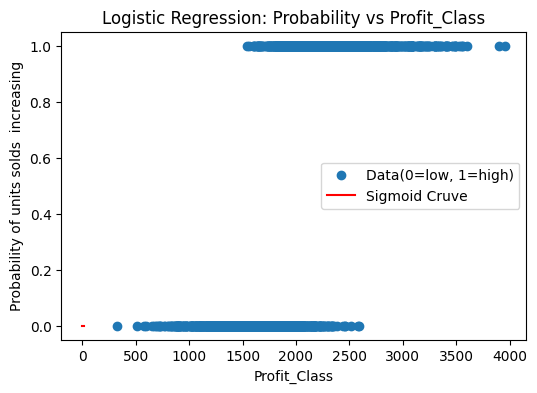

In [83]:
sales = np.linspace(0, 11, 200).reshape(-1, 1)
probability_curve = model.predict_proba(sales)[:, 1]

plt.figure(figsize=(6, 4))
plt.scatter(X["Units Sold"], y , label="Data(0=low, 1=high)")
plt.plot(sales, probability_curve, color="red", label="Sigmoid Cruve")
plt.xlabel("Profit_Class")
plt.ylabel("Probability of units solds  increasing")
plt.title("Logistic Regression: Probability vs Profit_Class")
plt.legend()
plt.show()

Implement the Linear Regression


Handling the Dates

In [90]:
#sort the dates
df=df.reset_index()
df['date']= pd.to_datetime(df['Date'])
df= df.sort_values('Date')

#aggregate by month
df.set_index('Date', inplace =True)
yearly_profit = df['Profit(£)'].resample('Y').sum().reset_index()


/tmp/ipykernel_2582/2004052049.py:8: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_profit = df['Profit(£)'].resample('Y').sum().reset_index()
